#### Auto Reloading for External Libraries

In [1]:
import numpy as np
from tqdm import tqdm
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Using this magic command, we turn on auto-reloading for libraries imported by %aimport
%load_ext autoreload
%autoreload 2
%aimport Sub
%aimport Master
%aimport DataPreparation
%aimport Functions

## 2. lp Box ADMM

In [245]:
# Build models
"""from Sub import Sub
from Master import Master
f = [Sub(data=mg_private[mg], trade=True, MIP=False) for mg in range(n_mgs)]
g = Master(data=cems)

y_shape, x_shape = g.yhat.shape, (N, T)

from ADMM import ADMM_env, ADMM_config
config = ADMM_config(y_shape=y_shape, x_shape=x_shape, is_lp_box=True)
admm = ADMM_env(f=f, g=g, config=config)

model_name = 'Box_ADMM_'
from ADMM import ADMM_run_config, ADMM_run
run_config = ADMM_run_config()
info, rhos, xs = ADMM_run(admm_env=admm, config=run_config, name_to_save=model_name, max_itr=600)
"""

"from Sub import Sub\nfrom Master import Master\nf = [Sub(data=mg_private[mg], trade=True, MIP=False) for mg in range(n_mgs)]\ng = Master(data=cems)\n\ny_shape, x_shape = g.yhat.shape, (N, T)\n\nfrom ADMM import ADMM_env, ADMM_config\nconfig = ADMM_config(y_shape=y_shape, x_shape=x_shape, is_lp_box=True)\nadmm = ADMM_env(f=f, g=g, config=config)\n\nmodel_name = 'Box_ADMM_'\nfrom ADMM import ADMM_run_config, ADMM_run\nrun_config = ADMM_run_config()\ninfo, rhos, xs = ADMM_run(admm_env=admm, config=run_config, name_to_save=model_name, max_itr=600)\n"

In [437]:
# Microgrids data
from DataPreparation import getMGData, getCEMSData
N = 3
T = 24
mg_private, mg_public = {}, {}
for n in range(N):
    mg_private[n], mg_public[n] = getMGData(N, n, T)
cems = getCEMSData(N, T, mg_public, mg_private)

# Build models
from Sub import Sub
from Master import Master
f = [Sub(data=mg_private[i], trade=True, MIP=False) for i in range(N)]
g = Master(data=cems)
name = 'RPADMM'

Set parameter Method to value 0


In [30]:
def retract(v, c, r):
    temp = v - c
    temp_norm = np.linalg.norm(temp, axis=1)
    temp_unit = np.array([nom / denom for nom, denom in zip(temp, temp_norm)])
    return c + r * temp_unit

In [467]:
# Parameters
y_shape, x_shape = g.yhat.shape, (N, T)
yhat, l_y = 100 * np.ones(y_shape), np.zeros(y_shape)
z, l_z = np.zeros(x_shape), np.zeros(x_shape)
c, r = 0.5 * np.ones((N, T)), np.sqrt(T)/2
rho_y, rho_z = 1e-7, 100
mu, tau = 10, 2
gamma, eta = 1000, 0.01
decay = 0.99
e_y, e_z = 5, 0.5

In [468]:
# RP-ADMM
from time import time
yhat_, z_ = yhat, z
prs, drs = [], []
itr = 0
max_itr = 1500
start = time()
for itr in tqdm(range(max_itr),desc='Progress'):
    # Solve f
    y, x = [], []
    for i, fi in enumerate(f):
        kwargs = {
            'yhat': yhat[:, i, :, :],
            'l_y': l_y[:, i, :, :],
            'rho_y': rho_y,
            'z': z[i, :],
            'l_z': l_z[i, :],
            'rho_z': rho_z,
            }
        yi, xi = fi.solve_with(**kwargs)
        y.append(yi)
        x.append(xi)
    y = np.transpose(np.stack(y, axis=0), (1, 0, 2, 3))
    x = np.stack(x, axis=0)

    # Solve g
    yhat = g.solve_with(y=y, rho_y=rho_y, l_y=l_y)

    # Update z
    lagrang_G = -l_z - rho_z * (x - z)
    penalty_G = gamma * (np.minimum(2 * z, 0) + np.maximum(2 * (z - 1), 0))
    G = lagrang_G + penalty_G
    v = z - c
    r2 = r ** 2
    vvT = np.array([vi[:, None] @ vi[:, None].T for vi in v])
    vvT /= r2
    vvTG = np.array([vvTi @ Gi for Gi, vvTi in zip(G, vvT)])
    grad_g = G - vvTG
    z -= eta * grad_g
    z = retract(z, c, r)

    # Gradient descent
    l_y += rho_y * (y - yhat)
    l_z += rho_z * (x - z)

    # Residuals
    pr = [np.linalg.norm(y - yhat), np.linalg.norm(x - z)]
    dr = [rho_y * np.linalg.norm(yhat - yhat_), rho_z * np.linalg.norm(z - z_)]
    done = all([pr[0]+dr[0] <= e_y, pr[1]+dr[1] <= e_z])
    (prs.append(pr), drs.append(dr))

    # Update itr
    itr += 1
    yhat_, z_ = yhat, z

    # Update rhos
    y_coef = tau if pr[0] >= mu * dr[0] else 1 / tau if dr[0] >= mu * pr[0] else 1
    z_coef = tau if pr[1] >= mu * dr[1] else 1 / tau if dr[1] >= mu * pr[1] else 1
    rho_y, rho_z = y_coef * rho_y, z_coef * rho_z
    eta *= decay if itr%10 == 0 else 1

    # Terminate
    if done:
        break
print(time() - start)

Progress: 100%|██████████| 1500/1500 [04:24<00:00,  5.67it/s]

264.54973459243774


In [477]:
sum(-fi.fixed_obj.getValue() for fi in f)

0.5609351800319731

In [470]:
np.linalg.norm(y[2, 0, 2] - y[3, 2, 0])

np.float64(0.05933444168984132)

In [471]:
x[0]

array([0.88101245, 0.7584233 , 0.79907901, 0.18654477, 0.2488034 ,
       0.75769655, 0.78317951, 0.22201383, 0.21326965, 0.06742609,
       0.74207508, 0.74882923, 0.74649966, 0.73265035, 0.06527986,
       0.87380692, 0.84517516, 0.06110195, 0.17471441, 0.14245194,
       0.23897986, 0.85381971, 0.22232   , 0.24750375])

In [443]:
f[0].e_sell[1].x

array([11.10675282, 30.53767405, 20.01127873, 15.9570457 , 12.49191355,
       31.26290121, 15.22752007, 16.39917478, 30.99516183, 30.97689323,
       31.25728136, 31.23399697, 31.14781793, 31.21010393, 30.97629658,
       24.33886925, 26.89533835, 21.13037958, 20.15896293, 26.92899304,
       26.81730993, 17.3265011 , 18.50541061,  9.51713493])

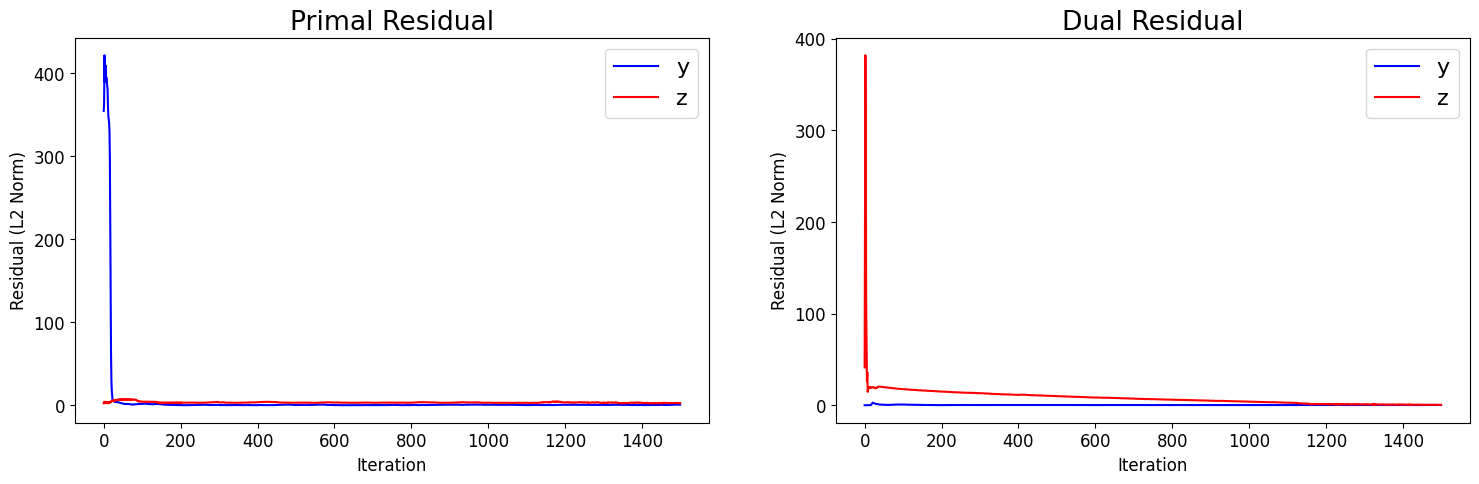

In [472]:
import matplotlib.pyplot as plt
y_primal, y_dual = np.stack(prs, axis=1), np.stack(drs, axis=1)

fig, axs = plt.subplots(1, 2, figsize=(18, 5))
plt.rcParams['font.size'] = 16
plt.subplots_adjust(hspace=0.6)

axs[0].plot(y_primal[0], label='y', color='blue')
axs[0].plot(y_primal[1], label='z', color='red')
axs[0].set_title('Primal Residual')

axs[1].plot(y_dual[0], label='y', color='blue')
axs[1].plot(y_dual[1], label='z', color='red')
axs[1].set_title('Dual Residual')
for ax in axs:
    ax.legend()
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual (L2 Norm)')

plt.savefig(f'Performance/residuals.jpg', dpi=600)

In [473]:
for n in range(N):
    kwargs = {
            'yhat': yhat[:, n, :, :],
            'l_y': l_y[:, n, :, :],
            'rho_y': rho_y,
            'z': z[n, :],
            'l_z': l_z[n, :],
            'rho_z': rho_z,
            }
    f[n].save_solutions(**kwargs, name=name)

In [474]:
from Results import *
name_to_save = 'RPADMM_'
results_before = {n: MGResults(f'NoTrade_MG({n})', mg_private[n]) for n in range(N)}
results_after = {n: MGResults(f'{name_to_save}MG({n})', mg_private[n]) for n in range(N)}

In [475]:
# Cost table
get_cost_table(results_before, results_after, N, name_to_save)

# Resilience and cost reduction
get_metric_table(results_before, results_after, N, name_to_save)

# KPI
get_kpi_table(results_after, N, name_to_save)

# Power table
get_power_table(results_after, N, name_to_save)

# Trade plot
plot_trade(results_after, name_to_save)

# Load satisfaction plot
plot_load_served(results_after, 1, name_to_save)

In [476]:
plot_trade(results_after, name_to_save)

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [62.37850459, 61.8483581 , 61.54814941, 63.27087871, 63.63006378,
        61.0614772 , 60.53654697, 57.73664798, 70.13400974, 69.64571159,
        68.33098112, 68.33127649, 68.33121252, 68.33095336, 68.63370485,
        50.53561609, 62.97782173, 57.91779942, 58.77417547, 59.10321972,
        59.38668839, 60.00892756, 59.46000779, 46.50320034],
       [49.55316071, 52.59572608, 52.19386087, 52.41448349, 51.65969843,
        50.17190666, 50.8005148 , 55.39012201, 59.68304898, 70.52335108,
        73.35426586, 73.3572601 , 73.36063572, 73.35875444, 72.69264789,
        55.01751283, 58.48181592, 49.06162335, 49.06865211, 49.12062213,
  

### lp-ADMM

In [24]:
y_shape, x_shape = g.yhat.shape, (N, T)
yhat, l_y = 100 * np.ones(y_shape), np.zeros(y_shape)
z1, l_z1 = np.zeros(x_shape), np.zeros(x_shape)
z2, l_z2 = np.zeros(x_shape), np.zeros(x_shape)
c, r = 0.5 * np.ones((N, T)), np.sqrt(T)/2
rho_y, rho_z1, rho_z2 = 1e-9, 10, 10
mu, tau = 10, 2
gamma, eta = 1000, 0.05
decay = 0.98
e_y, e_z = 0.5, 0.5

In [25]:
# MP-ADMM
from time import time
yhat_, z1_, z2_ = yhat, z1, z2
prs, drs = [], []
itr = 0
max_itr = 2000
start = time()
for itr in tqdm(range(max_itr)):
    # Solve f
    y, x = [], []
    for i, fi in enumerate(f):
        kwargs = {
            'yhat': yhat[:, i, :, :],
            'l_y': l_y[:, i, :, :],
            'rho_y': rho_y,
            'z1': z1[i, :],
            'l_z1': l_z1[i, :],
            'rho_z1': rho_z1,
            'z2': z2[i, :],
            'l_z2': l_z2[i, :],
            'rho_z2': rho_z2,
            }
        yi, xi = fi.solve_with_lp(**kwargs)
        y.append(yi)
        x.append(xi)
    y = np.transpose(np.stack(y, axis=0), (1, 0, 2, 3))
    x = np.stack(x, axis=0)

    # Solve g
    yhat = g.solve_with(y=y, rho_y=rho_y, l_y=l_y)

    # Update z1
    z1 = np.clip(z1 + l_z1/rho_z1, 0, 1)

    # Update z2
    z2 = retract(z2 + l_z2/rho_z2, c, r)

    # Gradient descent
    l_y += rho_y * (y - yhat)
    l_z1 += rho_z1 * (x - z1)
    l_z2 += rho_z2 * (x - z2)

    # Residuals
    pr = [np.linalg.norm(y - yhat), np.linalg.norm(x - z1), np.linalg.norm(x - z2)]
    dr = [rho_y * np.linalg.norm(yhat - yhat_), rho_z1 * np.linalg.norm(z1 - z1_), rho_z2 * np.linalg.norm(z2 - z2_)]
    done = all([pr[0] + dr[0] <= e_y, pr[1] + dr[1] <= e_z, pr[2] + dr[2] <= e_z])
    (prs.append(pr), drs.append(dr))

    # Update itr
    itr += 1
    yhat_, z1_, z2_ = yhat, z1, z2

    # Update rhos
    y_coef = tau if pr[0] >= mu * dr[0] else 1 / tau if dr[0] >= mu * pr[0] else 1
    z1_coef = tau if pr[1] >= mu * dr[1] else 1 / tau if dr[1] >= mu * pr[1] else 1
    z2_coef = tau if pr[2] >= mu * dr[2] else 1 / tau if dr[2] >= mu * pr[2] else 1
    rho_y, rho_z1, rho_z2 = y_coef * rho_y, z1_coef * rho_z1, z2_coef * rho_z2
    eta *= decay if itr%10 == 0 else 1

    # Terminate
    if done:
        break
print(time() - start)

100%|██████████| 2000/2000 [20:46<00:00,  1.60it/s]

1246.677610874176


In [26]:
sum(-fi.fixed_obj.getValue() for fi in f)

0.6398179040319427

In [19]:
x-z2

array([[-0.17881992, -0.12616594,  0.01232971,  0.01108839, -0.01171259,
        -0.28237179,  0.08702535, -0.01164096, -0.12091343,  0.18056526,
        -0.35637371,  1.04440759],
       [ 0.70281448, -0.3115652 ,  0.64520138,  0.62676726,  0.74517866,
        -0.04654783,  0.73961339,  0.69676967,  0.12913887,  0.69929627,
         0.30067795, -1.07362366],
       [-0.31141002, -0.23749355, -0.34506942, -0.38281679, -0.39458204,
         0.88878096, -0.12993287, -0.34551381,  2.06015296, -0.14211023,
         0.38669922, -0.26804819],
       [-0.2837053 , -0.25259813, -0.395982  , -0.28891216, -0.42292881,
         0.30806378, -0.32865663, -0.05602724,  0.05654797, -0.02530545,
         0.11499283, -1.81191066],
       [-0.35782466, -0.28251595, -0.38869921, -0.07710065, -0.3917351 ,
        -0.31380859, -0.03260974, -0.00280872, -0.37702574,  0.07546791,
         0.06037159,  2.15234797],
       [-0.40025255, -0.28959878, -0.36626373, -0.36987743, -0.38125803,
        -0.35699446,  

In [ ]:
from DPG_off import Agent_config, DPG_Agent
from ADMM import ADMM_env, DRL_ADMM_env, ADMM_config, DRL_config

config_admm = ADMM_config(y_shape=y_shape, x_shape=x_shape, is_lp_box=is_lp_box, xi=1)
admm_env = ADMM_env(f=drl_f, g=drl_g, config=config_admm)

config_drl = DRL_config()
drl_env = DRL_ADMM_env(env=admm_env, config=config_drl)

config_agent = Agent_config()
agent = DPG_Agent(env=drl_env, config=config_agent)

In [ ]:
agent.train(episodes=100, max_itr=20)

In [ ]:
info, rhos = agent.execute_policy(max_itr=300, load=True)

In [ ]:
for mg_id, model in enumerate(f):
    identifier = 'DRL_l2Box_ADMM_' + f'tau({f[mg_id].config.tau})_'
    model.save_solutions(
        yhat=info['yhat'][:, mg_id, :, :],
        l_yhat=info['l_yhat'][:, mg_id, :, :],
        rho_yhat= 4.7e-2,
        xi=1,
        identifier=identifier
    )

In [ ]:
results_after[0].vars['pi_sell']

In [ ]:
results_after[0].vars['e_buy']